In [1]:
import pandas as pd
import numpy as np

In [18]:
df= pd.read_csv(r'C:\Users\FatimaArain\Downloads\archive\retail_data\order_details.csv')

In [19]:
# check the data and find what can be done with thia data
df.head()

,OrderID,ProductID,Quantity,UnitCost,UnitPrice,DiscountRate,IsReturned,ReturnDate,ReturnTime,ReturnReason
0,ORD00001,PRDCT0056,3,2.14,3.38,0.00,0,9999-12-31,00:00:00,NaN
1,ORD00002,PRDCT0028,2,4.17,5.31,0.00,0,9999-12-31,00:00:00,NaN
2,ORD00002,PRDCT0001,13,20.36,25.77,0.05,0,9999-12-31,00:00:00,NaN
3,ORD00003,PRDCT0030,2,0.90,1.35,0.00,0,9999-12-31,00:00:00,NaN
4,ORD00004,PRDCT0003,3,12.84,20.35,0.00,0,9999-12-31,00:00:00,NaN


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30271 entries, 0 to 30270
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OrderID       30271 non-null  str    
 1   ProductID     30271 non-null  str    
 2   Quantity      30271 non-null  int64  
 3   UnitCost      30271 non-null  float64
 4   UnitPrice     30271 non-null  float64
 5   DiscountRate  30271 non-null  float64
 6   IsReturned    30271 non-null  int64  
 7   ReturnDate    30271 non-null  str    
 8   ReturnTime    30271 non-null  str    
 9   ReturnReason  1424 non-null   str    
dtypes: float64(3), int64(2), str(5)
memory usage: 3.3 MB


In [21]:
# extract categorial data
df['IsReturned'].unique()
cat = df.loc[:,['IsReturned']]


In [22]:
# varify
cat.shape
cat.dtypes
cat['IsReturned'].dtype

dtype('int64')

In [23]:
type(cat['IsReturned'])

pandas.Series

In [24]:
# exttact productID,qunatity and unit price
a=['ProductID','Quantity','UnitPrice']
cat['ProductID']= df['ProductID']
cat['Quantity']= df['Quantity']
cat['UnitPrice']=df['UnitPrice']

In [25]:
cat

,IsReturned,ProductID,Quantity,UnitPrice
0,0,PRDCT0056,3,3.38
1,0,PRDCT0028,2,5.31
2,0,PRDCT0001,13,25.77
3,0,PRDCT0030,2,1.35
4,0,PRDCT0003,3,20.35
...,...,...,...,...
30266,0,PRDCT0049,2,5.44
30267,0,PRDCT0052,3,4.71
30268,0,PRDCT0033,3,4.06
30269,0,PRDCT0030,1,1.64


In [26]:
# extraction
print(df.iloc[1])
print(df.iloc[5])
print(df.iloc[-1])

OrderID           ORD00002
ProductID        PRDCT0028
Quantity                 2
UnitCost              4.17
UnitPrice             5.31
DiscountRate           0.0
IsReturned               0
ReturnDate      9999-12-31
ReturnTime        00:00:00
ReturnReason           NaN
Name: 1, dtype: object
OrderID           ORD00004
ProductID        PRDCT0017
Quantity                 5
UnitCost              2.84
UnitPrice              3.6
DiscountRate           0.0
IsReturned               0
ReturnDate      9999-12-31
ReturnTime        00:00:00
ReturnReason           NaN
Name: 5, dtype: object
OrderID           ORD10000
ProductID        PRDCT0018
Quantity                 1
UnitCost              8.88
UnitPrice            11.66
DiscountRate          0.05
IsReturned               0
ReturnDate      9999-12-31
ReturnTime        00:00:00
ReturnReason           NaN
Name: 30270, dtype: object


In [27]:
# filter
avg = df['Quantity'].mean()
temp = df[df['Quantity'] > avg]

In [29]:

temp

,OrderID,ProductID,Quantity,UnitCost,UnitPrice,DiscountRate,IsReturned,ReturnDate,ReturnTime,ReturnReason
0,ORD00001,PRDCT0056,3,2.14,3.38,0.00,0,9999-12-31,00:00:00,NaN
2,ORD00002,PRDCT0001,13,20.36,25.77,0.05,0,9999-12-31,00:00:00,NaN
4,ORD00004,PRDCT0003,3,12.84,20.35,0.00,0,9999-12-31,00:00:00,NaN
5,ORD00004,PRDCT0017,5,2.84,3.60,0.00,0,9999-12-31,00:00:00,NaN
6,ORD00004,PRDCT0021,4,1.65,2.36,0.00,0,9999-12-31,00:00:00,NaN
...,...,...,...,...,...,...,...,...,...,...
30257,ORD09995,PRDCT0012,11,3.63,5.39,0.10,0,9999-12-31,00:00:00,NaN
30258,ORD09995,PRDCT0006,5,11.10,13.99,0.00,0,9999-12-31,00:00:00,NaN
30261,ORD09998,PRDCT0023,3,2.71,3.69,0.00,0,9999-12-31,00:00:00,NaN
30267,ORD09999,PRDCT0052,3,3.30,4.71,0.00,0,9999-12-31,00:00:00,NaN


In [30]:
avg

np.float64(2.681312146939315)

In [31]:
# use of and multi conditions 
return_rate=df['IsReturned'].mean()
# check the avg purchase qunatiy and avg is returned qunatiy greater then 
b = df[(df['IsReturned']> return_rate )& (df['Quantity']> avg)]

In [32]:
b.loc[:,['ProductID','IsReturned','Quantity']]

,ProductID,IsReturned,Quantity
35,PRDCT0029,1,18
61,PRDCT0016,1,3
88,PRDCT0001,1,4
89,PRDCT0027,1,3
140,PRDCT0025,1,8
...,...,...,...
30091,PRDCT0069,1,4
30140,PRDCT0085,1,4
30166,PRDCT0028,1,3
30229,PRDCT0090,1,3


In [ ]:
# problem 7
# | 
# check the product id is quantity is greater then avg or is returner
re = df['Quantity'].mean()

df.loc[(df['Quantity'] > re) | (df['IsReturned']==1), ['ProductID','Quantity','IsReturned']]

,OrderID,ProductID,Quantity,UnitCost,UnitPrice,DiscountRate,IsReturned,ReturnDate,ReturnTime,ReturnReason
0,ORD00001,PRDCT0056,3,2.14,3.38,0.00,0,9999-12-31,00:00:00,NaN
2,ORD00002,PRDCT0001,13,20.36,25.77,0.05,0,9999-12-31,00:00:00,NaN
4,ORD00004,PRDCT0003,3,12.84,20.35,0.00,0,9999-12-31,00:00:00,NaN
5,ORD00004,PRDCT0017,5,2.84,3.60,0.00,0,9999-12-31,00:00:00,NaN
6,ORD00004,PRDCT0021,4,1.65,2.36,0.00,0,9999-12-31,00:00:00,NaN
...,...,...,...,...,...,...,...,...,...,...
30257,ORD09995,PRDCT0012,11,3.63,5.39,0.10,0,9999-12-31,00:00:00,NaN
30258,ORD09995,PRDCT0006,5,11.10,13.99,0.00,0,9999-12-31,00:00:00,NaN
30261,ORD09998,PRDCT0023,3,2.71,3.69,0.00,0,9999-12-31,00:00:00,NaN
30267,ORD09999,PRDCT0052,3,3.30,4.71,0.00,0,9999-12-31,00:00:00,NaN


In [36]:
# problem 9 extract categorical data
cati = [df['IsReturned'] == 0 ]

In [37]:
cati

[0        True
 1        True
 2        True
 3        True
 4        True
          ... 
 30266    True
 30267    True
 30268    True
 30269    True
 30270    True
 Name: IsReturned, Length: 30271, dtype: bool]

In [38]:
# level 3
# make a new col profit 
df['Profit']= [True if i==1  else False  for i in df['IsReturned']] 

In [39]:
df.columns

Index(['OrderID', 'ProductID', 'Quantity', 'UnitCost', 'UnitPrice',
       'DiscountRate', 'IsReturned', 'ReturnDate', 'ReturnTime',
       'ReturnReason', 'Profit'],
      dtype='str')

In [40]:
df['Net_Profit'] = df['Quantity'] * (df['UnitPrice'] * (1 - df['DiscountRate']) - df['UnitCost'])

In [41]:
# find mising
df.isna().sum()

OrderID             0
ProductID           0
Quantity            0
UnitCost            0
UnitPrice           0
DiscountRate        0
IsReturned          0
ReturnDate          0
ReturnTime          0
ReturnReason    28847
Profit              0
Net_Profit          0
dtype: int64

In [43]:
# make a categorial col
# make a new column which describe the quantityt level low medium high
level=['Low','Medium','High']
avg = df['Quantity'].mean()
condition = [
    df['Quantity'] < avg,
   ( df['Quantity'] > avg )& (df['Quantity'] <=5),
   df['Quantity'] >5
]
df['Quantity_level'] = np.select(condition,level,default='Heighest')

In [44]:
df

,OrderID,ProductID,Quantity,UnitCost,UnitPrice,DiscountRate,IsReturned,ReturnDate,ReturnTime,ReturnReason,Profit,Net_Profit,Quantity_level
0,ORD00001,PRDCT0056,3,2.14,3.38,0.00,0,9999-12-31,00:00:00,NaN,False,3.7200,Medium
1,ORD00002,PRDCT0028,2,4.17,5.31,0.00,0,9999-12-31,00:00:00,NaN,False,2.2800,Low
2,ORD00002,PRDCT0001,13,20.36,25.77,0.05,0,9999-12-31,00:00:00,NaN,False,53.5795,High
3,ORD00003,PRDCT0030,2,0.90,1.35,0.00,0,9999-12-31,00:00:00,NaN,False,0.9000,Low
4,ORD00004,PRDCT0003,3,12.84,20.35,0.00,0,9999-12-31,00:00:00,NaN,False,22.5300,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30266,ORD09999,PRDCT0049,2,3.73,5.44,0.00,0,9999-12-31,00:00:00,NaN,False,3.4200,Low
30267,ORD09999,PRDCT0052,3,3.30,4.71,0.00,0,9999-12-31,00:00:00,NaN,False,4.2300,Medium
30268,ORD09999,PRDCT0033,3,2.87,4.06,0.00,0,9999-12-31,00:00:00,NaN,False,3.5700,Medium
30269,ORD10000,PRDCT0030,1,1.09,1.64,0.00,0,9999-12-31,00:00:00,NaN,False,0.5500,Low


In [45]:
# pro 11 
# find missing values
df.isna().sum()

OrderID               0
ProductID             0
Quantity              0
UnitCost              0
UnitPrice             0
DiscountRate          0
IsReturned            0
ReturnDate            0
ReturnTime            0
ReturnReason      28847
Profit                0
Net_Profit            0
Quantity_level        0
dtype: int64

In [50]:
# find percentage of missinng values
ob = df['ReturnReason'].isna().sum()

percentage =( ob/len(df)) * 100
percentage


KeyError: 'ReturnReason'

In [51]:
# 95% data is missing it would be okay to drop this columns
df = df.drop(columns='ReturnReason')

KeyError: "['ReturnReason'] not found in axis"

In [52]:
df

,OrderID,ProductID,Quantity,UnitCost,UnitPrice,DiscountRate,IsReturned,ReturnDate,ReturnTime,Profit,Net_Profit,Quantity_level
0,ORD00001,PRDCT0056,3,2.14,3.38,0.00,0,9999-12-31,00:00:00,False,3.7200,Medium
1,ORD00002,PRDCT0028,2,4.17,5.31,0.00,0,9999-12-31,00:00:00,False,2.2800,Low
2,ORD00002,PRDCT0001,13,20.36,25.77,0.05,0,9999-12-31,00:00:00,False,53.5795,High
3,ORD00003,PRDCT0030,2,0.90,1.35,0.00,0,9999-12-31,00:00:00,False,0.9000,Low
4,ORD00004,PRDCT0003,3,12.84,20.35,0.00,0,9999-12-31,00:00:00,False,22.5300,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...
30266,ORD09999,PRDCT0049,2,3.73,5.44,0.00,0,9999-12-31,00:00:00,False,3.4200,Low
30267,ORD09999,PRDCT0052,3,3.30,4.71,0.00,0,9999-12-31,00:00:00,False,4.2300,Medium
30268,ORD09999,PRDCT0033,3,2.87,4.06,0.00,0,9999-12-31,00:00:00,False,3.5700,Medium
30269,ORD10000,PRDCT0030,1,1.09,1.64,0.00,0,9999-12-31,00:00:00,False,0.5500,Low


In [53]:
# pro 13 sort and highest
df.groupby(['ProductID'])['Quantity'].sum().sort_values(ascending=False).head(10)

ProductID
PRDCT0030    1415
PRDCT0014    1203
PRDCT0009    1176
PRDCT0025    1165
PRDCT0021    1129
PRDCT0020    1104
PRDCT0028    1099
PRDCT0026    1095
PRDCT0018    1094
PRDCT0005    1092
Name: Quantity, dtype: int64

In [ ]:
# pro 14
# count frequncy
df['Quantity_level'].value_counts()

Quantity_level
Low       20438
Medium     8398
High       1435
Name: count, dtype: int64

In [54]:
# pro 15
# group by and aggregation
df.groupby(['ProductID'])['UnitPrice'].sum().sort_values(ascending=False).head(10)

ProductID
PRDCT0007    14403.86
PRDCT0005    13634.91
PRDCT0002    13584.97
PRDCT0010    10720.85
PRDCT0009     9976.71
PRDCT0001     9381.47
PRDCT0008     7245.01
PRDCT0003     6870.47
PRDCT0078     6122.44
PRDCT0071     6118.03
Name: UnitPrice, dtype: float64

In [55]:
# check the most product returned
df.groupby(['ProductID'])['IsReturned'].value_counts()

ProductID  IsReturned
PRDCT0001  0             362
           1              11
PRDCT0002  0             356
           1              12
PRDCT0003  0             369
                        ... 
PRDCT0098  1               6
PRDCT0099  0             122
           1               4
PRDCT0100  0             138
           1               8
Name: count, Length: 200, dtype: int64

In [56]:
# pro 17
# find the avrage of qunatity of each grop
df.groupby(['ProductID'])['Quantity'].mean(numeric_only=True).sort_values(ascending=False)

ProductID
PRDCT0032    3.254902
PRDCT0030    3.215909
PRDCT0045    3.195122
PRDCT0031    2.982143
PRDCT0025    2.979540
               ...   
PRDCT0049    2.368664
PRDCT0091    2.303704
PRDCT0095    2.286585
PRDCT0098    2.261538
PRDCT0099    2.126984
Name: Quantity, Length: 100, dtype: float64

In [57]:
# pro 17
# find the avrage of qunatity of each grop
df.groupby(['ProductID'])['Quantity'].std()

ProductID
PRDCT0001    3.640723
PRDCT0002    3.697993
PRDCT0003    2.864687
PRDCT0004    2.869171
PRDCT0005    3.222278
               ...   
PRDCT0096    3.946919
PRDCT0097    3.716075
PRDCT0098    2.118775
PRDCT0099    1.696981
PRDCT0100    2.806599
Name: Quantity, Length: 100, dtype: float64

In [58]:
# pro 19 multi thinking
# calculate count on 2 cat col
df.groupby(['ProductID','Quantity_level'])['IsReturned'].value_counts()

ProductID  Quantity_level  IsReturned
PRDCT0001  High            0              23
           Low             0             240
                           1               3
           Medium          0              99
                           1               8
                                        ... 
PRDCT0100  High            0               5
           Low             0              88
                           1               5
           Medium          0              45
                           1               3
Name: count, Length: 542, dtype: int64

In [ ]:
# pro 19
df.groupby(['IsReturned','Quantity_level']).value_counts().sort_values(ascending=False).head(12)

IsReturned  Quantity_level  OrderID   ProductID  Quantity  UnitCost  UnitPrice  DiscountRate  ReturnDate  ReturnTime
0           High            ORD00002  PRDCT0001  13        20.36     25.77      0.05          9999-12-31  00:00:00      1
                            ORD00006  PRDCT0015  12        4.99      8.19       0.00          9999-12-31  00:00:00      1
                            ORD00029  PRDCT0087  25        7.85      12.18      0.00          9999-12-31  00:00:00      1
                            ORD00037  PRDCT0024  11        2.18      3.10       0.00          9999-12-31  00:00:00      1
                            ORD00048  PRDCT0068  14        11.10     16.69      0.15          9999-12-31  00:00:00      1
                                      PRDCT0082  17        10.98     15.52      0.20          9999-12-31  00:00:00      1
                            ORD00052  PRDCT0003  24        11.67     18.50      0.00          9999-12-31  00:00:00      1
                            O

In [ ]:
# max ,min,count,mean
df.groupby(['ProductID'])['Quantity_level'].value_counts()

ProductID  Quantity_level
PRDCT0001  Low               243
           Medium            107
           High               23
PRDCT0002  Low               254
           Medium             93
                            ... 
PRDCT0099  Medium             30
           High                4
PRDCT0100  Low                93
           Medium             48
           High                5
Name: count, Length: 300, dtype: int64

In [59]:
df.groupby(['Quantity_level'])['UnitPrice'].mean()

Quantity_level
High      9.726544
Low       9.813408
Medium    9.758016
Name: UnitPrice, dtype: float64

In [ ]:
df.groupby(['Quantity_level'])['UnitPrice'].max()

Quantity_level
High      49.62
Low       49.62
Medium    49.62
Name: UnitPrice, dtype: float64

In [60]:
df.groupby(['Quantity_level'])['UnitPrice'].min()

Quantity_level
High      1.17
Low       1.17
Medium    1.17
Name: UnitPrice, dtype: float64

In [ ]:
df.groupby(['ProductID','Quantity_level'])['Quantity'].sum()

ProductID  Quantity_level
PRDCT0001  High              358
           Low               354
           Medium            363
PRDCT0002  High              337
           Low               396
                            ... 
PRDCT0099  Low               133
           Medium             97
PRDCT0100  High               79
           Low               133
           Medium            160
Name: Quantity, Length: 300, dtype: int64

In [61]:
# pro 20
# find which product ID has high quantity level avg
df.groupby(['ProductID'])['Quantity_level'].value_counts(normalize=True)*100

ProductID  Quantity_level
PRDCT0001  Low               65.147453
           Medium            28.686327
           High               6.166220
PRDCT0002  Low               69.021739
           Medium            25.271739
                               ...    
PRDCT0099  Medium            23.809524
           High               3.174603
PRDCT0100  Low               63.698630
           Medium            32.876712
           High               3.424658
Name: proportion, Length: 300, dtype: float64

In [76]:
# find Outlier
sr = df['Quantity'].sort_values().sort_values()
q1 = df['Quantity'].sort_values().quantile(0.25)
q2 =df['Quantity'].sort_values().median()
q3 = df['Quantity'].sort_values().quantile(0.75)
iqr =  q3 - q1
iqr
print(q1 , q3 , q2 )


1.0 3.0 2.0


In [75]:
# filter outliers
lower_bound = q1 -( 1.5 * iqr)
print(lower_bound)
upper_bound = q3 + (1.5 * iqr)
print(upper_bound)
out = df[df['Quantity'] > upper_bound]
out

-2.0
6.0


,OrderID,ProductID,Quantity,UnitCost,UnitPrice,DiscountRate,IsReturned,ReturnDate,ReturnTime,Profit,Net_Profit,Quantity_level
2,ORD00002,PRDCT0001,13,20.36,25.77,0.05,0,9999-12-31,00:00:00,False,53.5795,High
15,ORD00006,PRDCT0015,12,4.99,8.19,0.00,0,9999-12-31,00:00:00,False,38.4000,High
35,ORD00012,PRDCT0029,18,1.35,2.11,0.00,1,2025-06-09,22:56:54,True,13.6800,High
83,ORD00029,PRDCT0087,25,7.85,12.18,0.00,0,9999-12-31,00:00:00,False,108.2500,High
107,ORD00037,PRDCT0024,11,2.18,3.10,0.00,0,9999-12-31,00:00:00,False,10.1200,High
...,...,...,...,...,...,...,...,...,...,...,...,...
30189,ORD09974,PRDCT0050,16,2.11,3.38,0.20,0,9999-12-31,00:00:00,False,9.5040,High
30192,ORD09974,PRDCT0038,12,6.47,8.68,0.25,0,9999-12-31,00:00:00,False,0.4800,High
30219,ORD09983,PRDCT0022,19,1.10,1.42,0.00,0,9999-12-31,00:00:00,False,6.0800,High
30222,ORD09983,PRDCT0019,16,3.10,5.00,0.00,0,9999-12-31,00:00:00,False,30.4000,High


<Axes: xlabel='Quantity', ylabel='Count'>

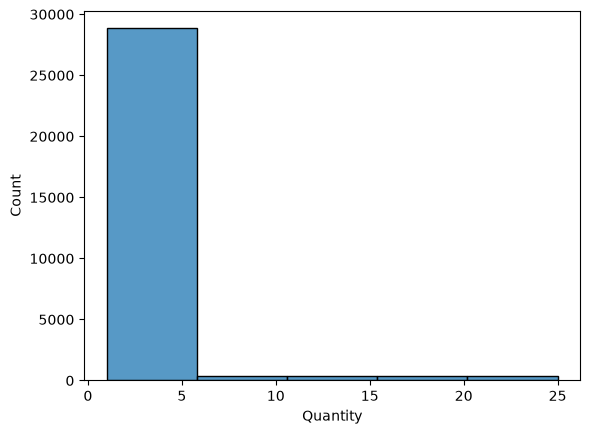

In [77]:
import seaborn as sb

sb.histplot(x = df['Quantity'],bins = 5)

In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30271 entries, 0 to 30270
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   OrderID         30271 non-null  str    
 1   ProductID       30271 non-null  str    
 2   Quantity        30271 non-null  int64  
 3   UnitCost        30271 non-null  float64
 4   UnitPrice       30271 non-null  float64
 5   DiscountRate    30271 non-null  float64
 6   IsReturned      30271 non-null  int64  
 7   ReturnDate      30271 non-null  str    
 8   ReturnTime      30271 non-null  str    
 9   Profit          30271 non-null  bool   
 10  Net_Profit      30271 non-null  float64
 11  Quantity_level  30271 non-null  str    
dtypes: bool(1), float64(4), int64(2), str(5)
memory usage: 3.7 MB


In [81]:
df['ReturnDate'] = pd.to_datetime(df['ReturnDate'])
df['ReturnDate']

0       9999-12-31
1       9999-12-31
2       9999-12-31
3       9999-12-31
4       9999-12-31
           ...    
30266   9999-12-31
30267   9999-12-31
30268   9999-12-31
30269   9999-12-31
30270   9999-12-31
Name: ReturnDate, Length: 30271, dtype: datetime64[us]

In [80]:
# make  a year col
import datetime as dt
df['year']  = df['ReturnDate'].dt.year
df['year']

0        9999
1        9999
2        9999
3        9999
4        9999
         ... 
30266    9999
30267    9999
30268    9999
30269    9999
30270    9999
Name: year, Length: 30271, dtype: int32

In [84]:
# month
df['month'] = df['ReturnDate'].dt.month_name()

In [85]:
df['month']

0        December
1        December
2        December
3        December
4        December
           ...   
30266    December
30267    December
30268    December
30269    December
30270    December
Name: month, Length: 30271, dtype: str

In [95]:
df['year'].value_counts()
# replace 9999 with 1999
df['year']=  df['year'].replace(9999,1999)

In [96]:
#now check the in which year most products saled
df.groupby(['year'])['Quantity'].sum().sort_values(ascending=False).head(10)


year
1999    77349
2023     1005
2024      877
2025      811
2022      451
2026      364
2021      309
Name: Quantity, dtype: int64

In [97]:
# check in which year most product returned
data = df[df['IsReturned'] == 1]
data
data.groupby(['month'])['IsReturned'].sum()

month
April        129
August       113
December     111
February     107
January      105
July         106
June         112
March        153
May          145
November     112
October      111
September    120
Name: IsReturned, dtype: int64

In [99]:
# now check which prodcut most saled in which year
df.groupby(['year','ProductID'])['Quantity'].sum()

year  ProductID
1999  PRDCT0001    1042
      PRDCT0002    1009
      PRDCT0003     959
      PRDCT0004     975
      PRDCT0005    1056
                   ... 
2026  PRDCT0090       8
      PRDCT0091       3
      PRDCT0092       8
      PRDCT0095       4
      PRDCT0097       4
Name: Quantity, Length: 611, dtype: int64

In [115]:
# level 7 split data set and merge
half1 = df[['ProductID','UnitPrice','Quantity']]
half1

,ProductID,UnitPrice,Quantity
0,PRDCT0056,3.38,3
1,PRDCT0028,5.31,2
2,PRDCT0001,25.77,13
3,PRDCT0030,1.35,2
4,PRDCT0003,20.35,3
...,...,...,...
30266,PRDCT0049,5.44,2
30267,PRDCT0052,4.71,3
30268,PRDCT0033,4.06,3
30269,PRDCT0030,1.64,1


In [116]:
#half 2
half2 = df[['DiscountRate','ProductID','UnitCost']]

In [117]:
# half 1 merge with half2
join_merge = half1.merge(half2)

In [118]:
join_merge

,ProductID,UnitPrice,Quantity,DiscountRate,UnitCost
0,PRDCT0056,3.38,3,0.00,2.14
1,PRDCT0056,3.38,3,0.15,3.13
2,PRDCT0056,3.38,3,0.00,2.85
3,PRDCT0056,3.38,3,0.00,2.85
4,PRDCT0056,3.38,3,0.00,2.59
...,...,...,...,...,...
9816908,PRDCT0018,11.66,1,0.00,8.07
9816909,PRDCT0018,11.66,1,0.00,8.07
9816910,PRDCT0018,11.66,1,0.05,8.07
9816911,PRDCT0018,11.66,1,0.10,8.88


In [122]:
# concat
total_ = pd.concat([half1,half2],ignore_index=True)

In [123]:
total_

,ProductID,UnitPrice,Quantity,DiscountRate,UnitCost
0,PRDCT0056,3.38,3.0,NaN,NaN
1,PRDCT0028,5.31,2.0,NaN,NaN
2,PRDCT0001,25.77,13.0,NaN,NaN
3,PRDCT0030,1.35,2.0,NaN,NaN
4,PRDCT0003,20.35,3.0,NaN,NaN
...,...,...,...,...,...
60537,PRDCT0049,NaN,NaN,0.00,3.73
60538,PRDCT0052,NaN,NaN,0.00,3.30
60539,PRDCT0033,NaN,NaN,0.00,2.87
60540,PRDCT0030,NaN,NaN,0.00,1.09


In [125]:
join_merge.value_counts()

ProductID  UnitPrice  Quantity  DiscountRate  UnitCost
PRDCT0029  1.92       1         0.00          1.22        3198
PRDCT0005  36.65      1         0.00          27.17       3078
PRDCT0009  25.78      2         0.00          18.17       3042
PRDCT0028  4.83       1         0.00          3.79        3010
PRDCT0005  30.29      1         0.00          27.17       2997
                                                          ... 
PRDCT0012  5.39       11        0.25          3.00           1
                                0.15          3.00           1
                                0.30          3.00           1
                                0.40          3.63           1
                                0.30          4.40           1
Name: count, Length: 140658, dtype: int64